#1 - Preprocessing


2026-04-06 00:42:41,828 | INFO | Image loaded: C:\Users\vitor\Desktop\Programa_Coquinas\Imagens Originais\Calibracao\Plug_II_Z_X+2.jpg | shape=(941, 453, 3)


Morphological step edges_binary done.
Morphological step black_mask_eroded done
Morphological step black_mask_sensitive done
Morphological step black_mask_sensitive_2 done
Morphological step black_mask_eroded_otsu_binary_mask done.
Morphological step black_mask_eroded_otsu_new_mask done.
Morphological step black_mask_eroded_otsu_final_mask done.
Morphological step black_mask_eroded_otsu_good_mask done.
Morphological step black_mask_sensitive_binary_mask done.
Morphological step black_mask_sensitive_new_mask done.
Morphological step black_mask_sensitive_final_mask done.
Morphological step black_mask_sensitive_good_mask done.
Morphological step black_mask_sensitive_2_binary_mask done.
Morphological step black_mask_sensitive_2_new_mask done.
Morphological step black_mask_sensitive_2_final_mask done.
Morphological step black_mask_sensitive_2_good_mask done.
Morphological step combined_good_mask done
Morphological step combined_good_mask_filtered done.
Morphological step edge_mask_dilated d

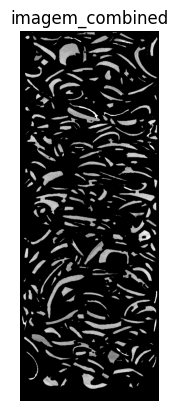


#2 - Object Detection
Saved plot as c:\Users\vitor\Desktop\Programa_Coquinas\Codigos\current/2 - Object Detection.png


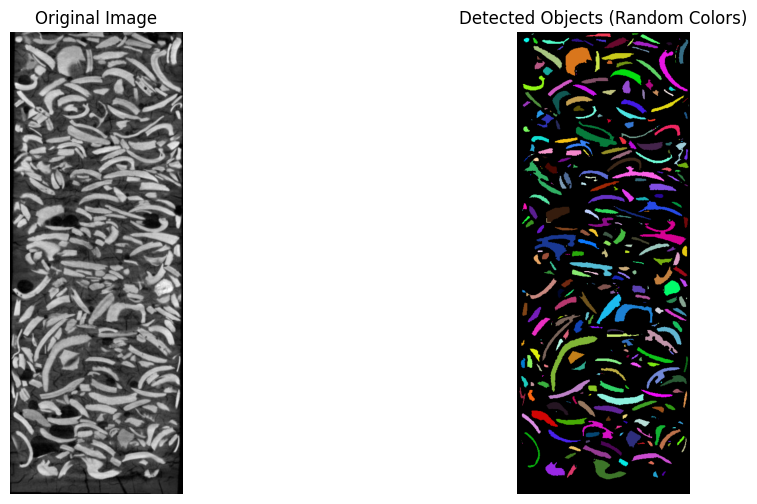

407 Objects found

#3 - Object Classification
[DEBUG] classify_objects started
Means -> width: 7.58 mm | thickness: 0.37 mm

[Summary] Count by label: {'sand': 149, 'fragment': 165, 'shell': 93}
[Summary] Top 5 reasons: [('frag_by_diag', 154), ('sand_by_diag', 134), ('default_shell', 93), ('sand_by_width', 15), ('frag_by_thickness_len', 6)]
[Summary] CSV saved to: current/classification_observations.csv

[Coverage] By label (counts and % of total):
  - sand     :  149  ( 36.6%)
  - fragment :  165  ( 40.5%)
  - shell    :   93  ( 22.9%)

[Coverage] Main reasons (global):
  - frag_by_diag          :  154  ( 37.8%)
  - sand_by_diag          :  134  ( 32.9%)
  - default_shell         :   93  ( 22.9%)
  - sand_by_width         :   15  (  3.7%)
  - frag_by_thickness_len :    6  (  1.5%)
  - frag_by_brightness    :    3  (  0.7%)
  - frag_by_circularity   :    2  (  0.5%)

[Coverage] Reasons by label (within-group participation):
  > sand (N=149)
    - sand_by_diag          :  134  ( 89.9% o

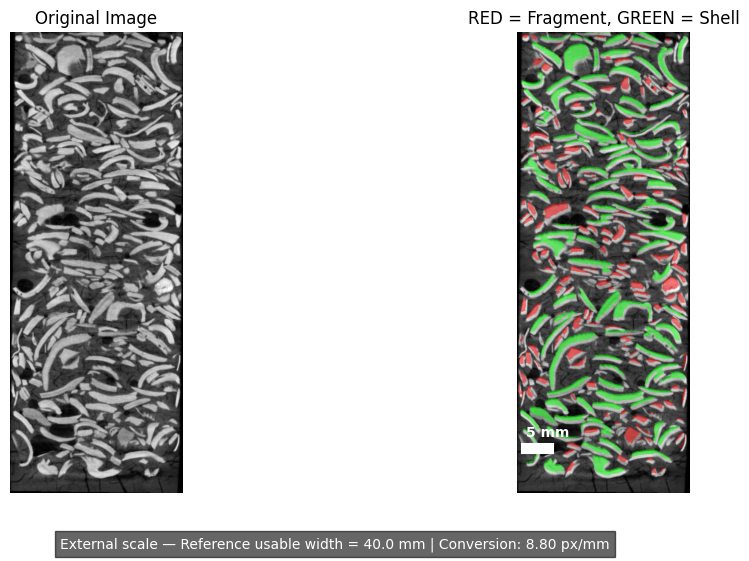

165 fragments and 93 shells found.
By count -> Shells: 36.0% | Fragments: 64.0%
By area  -> Shells: 71.1% | Fragments: 28.9%
Final mean -> Shells: 53.6% | Fragments: 46.4%
Saved plot as c:\Users\vitor\Desktop\Programa_Coquinas\Codigos\current/3b - Object Classification Chart.png


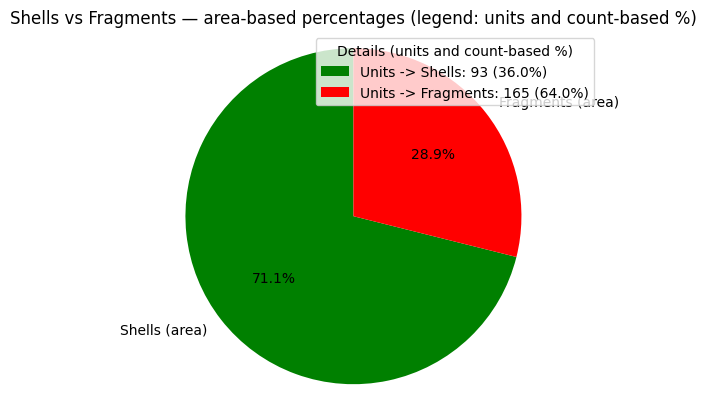


#4 - Angle Classification
Saved plot as c:\Users\vitor\Desktop\Programa_Coquinas\Codigos\current/4a - Angle Classification.png


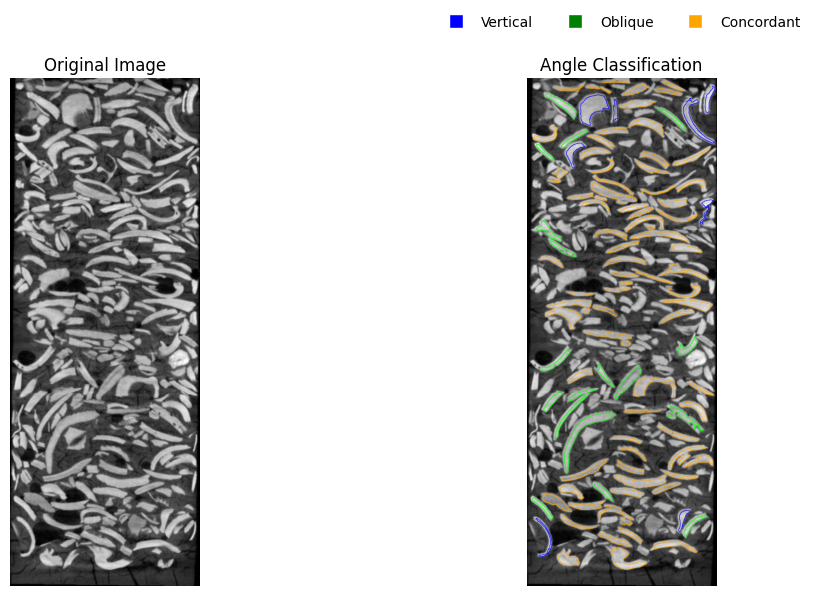

8 vertical, 16 oblique and 69 concordant.

Saved plot as c:\Users\vitor\Desktop\Programa_Coquinas\Codigos\current/4b - Angle Classification Pie Chart.png


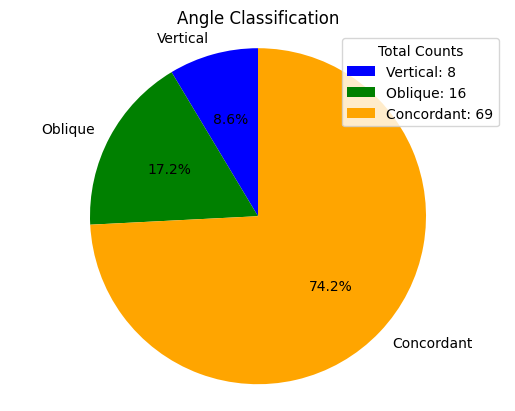

#5 - Concavity Classification
Saved plot as c:\Users\vitor\Desktop\Programa_Coquinas\Codigos\current/5a - Concavity Classification.png


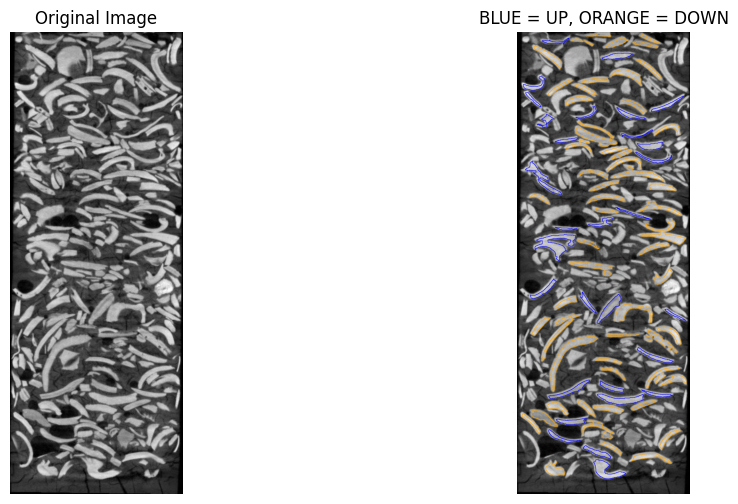

30 shells UP and 55 shells down.
Saved plot as c:\Users\vitor\Desktop\Programa_Coquinas\Codigos\current/5b - Concavity Classification Chart.png


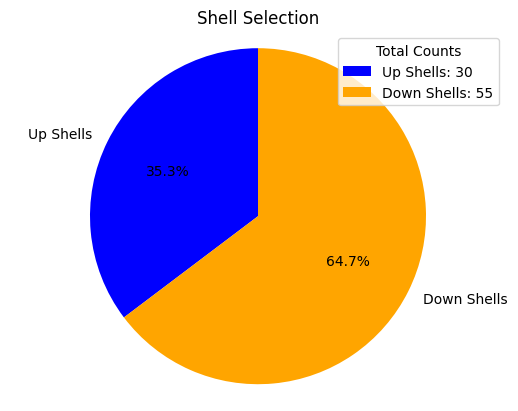


#6 - Analysis - Average Measurements
Saved plot as c:\Users\vitor\Desktop\Programa_Coquinas\Codigos\current/6a - Analysis - Average Length.png


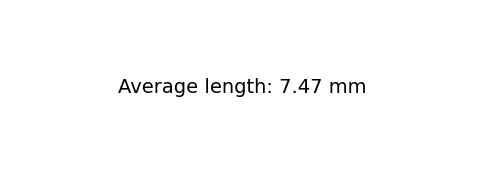

Saved plot as c:\Users\vitor\Desktop\Programa_Coquinas\Codigos\current/6b - Analysis - Average Thickness.png


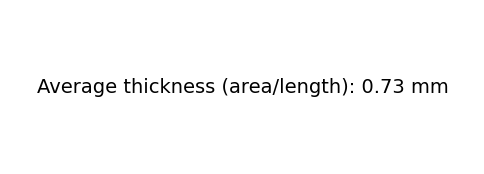

Average length in mm: 7.474
Average thickness in mm (area/length): 0.735


================ TEMPOS DE EXECUÇÃO ================
Tempo de espera do usuário : 8.12 s
Tempo de processamento     : 7.68 s
Tempo total do algoritmo   : 15.80 s



In [ ]:
# ==================================================================================================
# CoquinasID (Version 1)
# Automated workflow for object detection and morphologic classification
# in micro-CT images of synthetic coquinas.
#
# This codebase combines preprocessing, object detection, and rule-based
# classification to support the identification of shells, fragments, and sand.
# ==================================================================================================

# ============================
# CORE IMPORTS
# ============================
import os
import sys
import math
import csv
import json
import warnings
import time
from dataclasses import dataclass
from collections import Counter

import cv2
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.ndimage import binary_fill_holes, convolve

# ============================
# LOGGING
# ============================
import logging

logging.basicConfig(
    level=logging.INFO,  # Set to logging.DEBUG for more detailed output
    format="%(asctime)s | %(levelname)s | %(message)s",
)
LOG = logging.getLogger("coquinas")

# ============================
# FIGURE DISPLAY SETTINGS
# - Displays figures inline in Jupyter
# - Displays figures in a GUI window when running as a script
# - Suppresses unnecessary backend warnings
# ============================
warnings.filterwarnings(
    "ignore",
    message="FigureCanvasAgg is non-interactive, and thus cannot be shown",
    category=UserWarning
)

# Force inline backend when running in Jupyter
try:
    if 'ipykernel' in sys.modules:
        mpl.use('module://matplotlib_inline.backend_inline', force=True)
except Exception:
    pass

# Plot behavior flags
SHOW_PLOTS: bool = True    # Display figures (inline or GUI)
SAVE_PLOTS: bool = True    # Save figures to disk

# Working directory (if empty, the current directory is used)
WORKING_PATH: str = ""

def PlotShowOrSave(filename: str = "output.png", show: bool = True, close: bool = True) -> None:
    """
    Save and optionally display the current figure.

    Parameters
    ----------
    filename : str
        Output filename for the saved figure.
    show : bool
        If True, display the figure after saving.
    close : bool
        If True, close the figure after saving/displaying to avoid memory buildup.

    Notes
    -----
    The original function name and behavior were preserved for compatibility
    with the rest of the codebase.
    """
    # Use WORKING_PATH if defined; otherwise fall back to the current directory
    base_path = WORKING_PATH or os.getcwd()
    full_path = os.path.join(base_path, filename)

    # Ensure the output directory exists
    folder = os.path.dirname(full_path)
    if folder and not os.path.exists(folder):
        os.makedirs(folder)

    # Save figure to disk
    if SAVE_PLOTS and filename:
        plt.savefig(full_path, bbox_inches="tight")
        print(f"Saved plot as {full_path}")

    # Display figure when enabled
    if SHOW_PLOTS and show:
        try:
            plt.show()
        except Exception:
            # Safe fallback for non-interactive environments
            pass

    # Close figure to release memory
    if close:
        plt.close()

# ============================
# GLOBAL SETTINGS (PHYSICAL SCALE)
# ============================
# Effective image width used for physical scaling
MM_IMAGE_WIDTH: float = 40.0  # Approximate usable image width in mm

# ============================
# CLASSIFICATION PARAMETERS
# Physical (mm) and geometric (dimensionless) thresholds used by the classifier
# ============================
@dataclass
class ClassifyConfig:
    # --- Physical thresholds (mm) ---
    sand_max_width_min_mm: float = 25.15   # Sand criterion based on maximum width
    sand_min_diag_mm: float = 3.05         # Sand criterion based on diagonal length
    sand_min_width_mm: float = 2.75        # Sand criterion based on minimum width
    frag_diag_max_mm: float = 14           # Fragment threshold based on diagonal length
    frag_curve_len_max_mm: float = 9.5     # Fragment threshold based on curve length
    band_mm: float = 0.0                   # Uncertainty band (0 = disabled)

    # --- Dimensionless thresholds ---
    min_brightness: float = 47.5           # Low brightness favors fragment classification
    thickness_length_strong: float = 0.38  # High relative thickness favors fragment classification
    thickness_length_soft: float = 0.30    # Intermediate relative thickness favors fragment classification
    circularity_hi: float = 0.50           # High circularity favors fragment classification
    circularity_area_hi: float = 3.30      # Circularity-area criterion for fragments

    # --- Micro-fragment gate (minimum physical size) ---
    # Designed to capture very small fragments that may otherwise be misclassified as shells.
    # This gate evaluates curve length and maximum width simultaneously in millimeters.
    # Objects that are small in both dimensions are reclassified as fragments.
    microfrag_len_mm: float = 5.0    # Curve length threshold for micro-fragments
    microfrag_width_mm: float = 3.0  # Maximum width threshold for micro-fragments
    microfrag_diag_mm: float = 0.0   # Optional third condition (0 = disabled)

CFG = ClassifyConfig()  # Global classifier configuration

# ============================
# PREPROCESSING PARAMETER CENTRALIZATION
# ============================
@dataclass
class PreprocessConfig:
    edgemask_watershed_thresholds: tuple = (0.0004, 0.005, 0.01, 0.05)
    mask_low_brightness_threshold: int = 160
    mask_high_brightness_threshold: int = 210
    valid_contour_avg_color: int = 160
    canny_edges_lower: int = 100
    canny_edges_upper: int = 200
    scale_multiplier_mm: float = 40.0  # Physical scale reference in mm
    width_groups: tuple = (
        ("I", 3, 4), ("II", 4, 5), ("III", 5, 6),
        ("IV", 6, 8), ("V", 8, 10), ("VI", 10, 15), ("VII", 15, 20),
    )

PRE = PreprocessConfig()

# --- Compatibility layer: preserves the global names already used by the main code ---
EDGEMASK_WATERSHED_THRESHOLDS = list(PRE.edgemask_watershed_thresholds)
MASK_LOW_BRIGHTNESS_THRESHOLD  = PRE.mask_low_brightness_threshold
MASK_HIGH_BRIGHTNESS_THRESHOLD = PRE.mask_high_brightness_threshold
VALID_CONTOUR_AVG_COLOR        = PRE.valid_contour_avg_color
CANNY_EDGES_LOWER              = PRE.canny_edges_lower
CANNY_EDGES_UPPER              = PRE.canny_edges_upper
SCALE_MULTIPLIER               = PRE.scale_multiplier_mm
WIDTH_GROUPS                   = list(PRE.width_groups)

# Read-only semantic aliases
CANNY_THRESHOLDS = (CANNY_EDGES_LOWER, CANNY_EDGES_UPPER)
EDGE_STEPS = EDGEMASK_WATERSHED_THRESHOLDS

# ============================
# HELPER / GLOBAL FUNCTIONS
# ============================
def get_image_filename() -> str:
    """Prompt the user for the image file path and return it as a string."""
    return input("Enter the image file path: ").strip()

def request_image():
    """
    Define WORKING_PATH, load the input image, and return (image, filename).

    Behavior
    --------
    - Uses the script directory when running as a .py file
    - Falls back to the current working directory in Jupyter or environments without __file__
    - Stops execution if the image path is missing or invalid
    """
    global WORKING_PATH
    try:
        WORKING_PATH = os.path.dirname(os.path.abspath(__file__))  # Script directory
    except NameError:
        WORKING_PATH = os.getcwd()  # Jupyter or environments without __file__

    filename = get_image_filename().strip().strip('"').strip("'")
    if not filename:
        LOG.error("Image path not provided.")
        print("Error: image path not provided.")
        sys.exit(1)

    if not os.path.exists(filename):
        LOG.error(f"Path does not exist: {filename}")
        print(f"Error: path does not exist: {filename}")
        sys.exit(1)

    image = cv2.imread(filename)
    if image is None or getattr(image, "size", 0) == 0:
        LOG.error(f"Failed to load image (cv2.imread returned None): {filename}")
        print("Error: Unable to load the image. Please check the file path.")
        sys.exit(1)

    LOG.info(f"Image loaded: {filename} | shape={image.shape}")
    return image, filename

def ensure_dir(path: str) -> None:
    """Ensure that the target directory exists."""
    folder = os.path.dirname(path)
    if folder and not os.path.exists(folder):
        os.makedirs(folder)

def save_json(path: str, data) -> None:
    """Save a Python object as a UTF-8 formatted JSON file."""
    ensure_dir(path)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)

def to_gray(img):
    """Convert a BGR image to grayscale when needed; otherwise return it unchanged."""
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img


##################################
# PREPROCESSING FUNCTIONS (STEP 1)
#################################

def recortar_area_interesse(imagem):
    """
    Automatically crops the largest area of interest (AOI) in the image.

    If no contours are found, the original image is returned.
    """
    if imagem is None or imagem.size == 0:
        print("Error: Invalid input image")
        return None

    imagem_cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
    _, imagem_thresh = cv2.threshold(imagem_cinza, 30, 255, cv2.THRESH_BINARY)
    contornos, _ = cv2.findContours(imagem_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contornos:
        print("No area of interest detected.")
        return imagem

    x, y, w, h = cv2.boundingRect(max(contornos, key=cv2.contourArea))
    return imagem[y:y+h, x:x+w]


def ColorLayer(image_to_thresh, lower_bound, upper_bound):
    """
    Generates a binary mask based on intensity thresholding.

    Workflow:
    - Applies cv2.inRange()
    - Applies light erosion to reduce noise
    - Inverts the mask to highlight regions outside the selected range

    Returns
    -------
    uint8 mask with values {0, 255}
    """
    if image_to_thresh is None:
        return None

    mask = cv2.inRange(image_to_thresh, lower_bound, upper_bound)
    mask = cv2.erode(mask, np.ones((2, 2), np.uint8), iterations=4)
    return 255 - mask


def FindEdgesWaterShed(image_obj, dist_thresh):
    """
    Performs watershed segmentation based on distance transform.

    Returns only the boundary mask (separation pixels between markers).
    """
    imagem_raw = cv2.cvtColor(image_obj, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(imagem_raw, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    cv2.normalize(dist_transform, dist_transform, 0, 1.0, cv2.NORM_MINMAX)

    _, sure_fg = cv2.threshold(dist_transform, dist_thresh * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    sure_bg = cv2.dilate(binary, np.ones((2, 2), np.uint8), iterations=6)
    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    img_bgr = image_obj.copy()
    markers = cv2.watershed(img_bgr, markers)

    edge_mask = np.zeros_like(imagem_raw)
    edge_mask[markers == -1] = 255
    return edge_mask


def measure_noise_canny(image, lower_threshold=50, upper_threshold=150):
    """
    Estimates edge noise using the Canny detector.

    Returns
    -------
    noise_score : float
        Percentage of edge pixels relative to total pixels
    edges : ndarray
        Binary edge map
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blurred, lower_threshold, upper_threshold)

    edge_pixel_count = np.count_nonzero(edges)
    total_pixel_count = edges.size

    noise_score = (edge_pixel_count / total_pixel_count) * 100.0
    return noise_score, edges


def process_mask_pipeline(mask, output_prefix, min_area=450, thickness_threshold=10.5, diagonal_threshold=80):
    """
    Standard morphological processing pipeline.

    Steps:
    - Binary normalization
    - Removal of dense pixel neighborhoods (3x3 full blocks)
    - Morphological smoothing (dilate/erode)
    - Contour filtering based on area and shape
    - Returns a refined mask (good_mask)

    Notes
    -----
    Progress logs are printed using the provided output_prefix.
    """

    # Convert mask to binary {0,1}
    binary_mask = (mask // 255).astype(np.uint8)
    print(f"Morphological step {output_prefix}_binary_mask done.")

    # Remove compact 3x3 regions (fully filled neighborhoods)
    kernel_conv = np.ones((3, 3), dtype=np.uint8)
    convolved = convolve(binary_mask, kernel_conv, mode='constant', cval=0)

    new_mask = binary_mask.copy()
    new_mask[(binary_mask == 1) & (convolved == 9)] = 0
    print(f"Morphological step {output_prefix}_new_mask done.")

    # Morphological smoothing (dilate → erode → light dilate)
    new_mask_uint8 = (new_mask * 255).astype(np.uint8)
    kernel_morph = np.ones((3, 3), np.uint8)

    dilated = cv2.dilate(new_mask_uint8, kernel_morph, iterations=5)
    final_mask = cv2.erode(dilated, kernel_morph, iterations=6)
    final_mask = cv2.dilate(final_mask, kernel_morph, iterations=1)

    print(f"Morphological step {output_prefix}_final_mask done.")

    # Contour filtering (area + geometric constraints)
    contours, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

    good_contours = []
    for cnt in filtered_contours:
        area = cv2.contourArea(cnt)
        x, y, w, h = cv2.boundingRect(cnt)

        diagonal = math.hypot(w, h)
        thickness = area / diagonal if diagonal > 0 else 0.0

        if (thickness < thickness_threshold) and (diagonal > diagonal_threshold):
            good_contours.append(cnt)

    good_mask = np.zeros_like(final_mask)
    cv2.drawContours(good_mask, good_contours, -1, 255, thickness=cv2.FILLED)

    # Light erosion for refinement
    good_mask = cv2.erode(good_mask, np.ones((3, 3), np.uint8), iterations=1)

    print(f"Morphological step {output_prefix}_good_mask done.")
    return good_mask


def preprocess_image(imagem_cortada):
    """
    Main preprocessing pipeline.

    Workflow:
    - Multi-scale watershed edge detection
    - Dark-region masking (Otsu + intensity thresholds)
    - Morphological filtering pipelines
    - Background correction
    - Noise reduction (fastNlMeans)
    - Contrast enhancement (CLAHE)
    - Edge extraction (Canny)
    - Final binary combination

    Output
    ------
    Binary image used as input for subsequent processing steps.

    Also saves a preprocessing figure at:
    'current/1 - Preprocessing.png'
    """

    # Base grayscale and scaled versions
    imagem_gray_small = cv2.cvtColor(imagem_cortada, cv2.COLOR_BGR2GRAY)
    imagem_zoom = cv2.resize(imagem_cortada, None, fx=3, fy=3, interpolation=cv2.INTER_LINEAR)
    imagem_gray = cv2.cvtColor(imagem_zoom, cv2.COLOR_BGR2GRAY)

    # --- Multi-scale watershed edges ---
    edge_mask_combined = np.zeros_like(imagem_gray)
    last_edge_mask = None

    for size in EDGEMASK_WATERSHED_THRESHOLDS:
        last_edge_mask = FindEdgesWaterShed(imagem_zoom, size)
        edge_mask_combined = cv2.bitwise_or(edge_mask_combined, last_edge_mask)

    cv2.imwrite("edges_binary.jpg", edge_mask_combined)  # Optional debug output
    print("Morphological step edges_binary done.")

    # --- Dark region masks ---
    _, black_mask = cv2.threshold(imagem_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    black_mask_eroded = cv2.erode(black_mask, np.ones((2, 2), np.uint8), iterations=6)
    print("Morphological step black_mask_eroded done")

    black_mask_sensitive   = ColorLayer(imagem_gray, 0, MASK_LOW_BRIGHTNESS_THRESHOLD)
    print("Morphological step black_mask_sensitive done")

    black_mask_sensitive_2 = ColorLayer(imagem_gray, 0, MASK_HIGH_BRIGHTNESS_THRESHOLD)
    print("Morphological step black_mask_sensitive_2 done")

    # --- Independent morphological pipelines ---
    good_mask_black_otsu       = process_mask_pipeline(black_mask_eroded,     "black_mask_eroded_otsu")
    good_mask_black_sensitive  = process_mask_pipeline(black_mask_sensitive,  "black_mask_sensitive")
    good_mask_black_sensitive2 = process_mask_pipeline(black_mask_sensitive_2,"black_mask_sensitive_2")

    # --- Combine masks ---
    combined_good_mask = cv2.bitwise_or(good_mask_black_sensitive,  good_mask_black_sensitive2)
    combined_good_mask = cv2.bitwise_or(combined_good_mask,         good_mask_black_otsu)

    print("Morphological step combined_good_mask done")

    # --- Filter contours by internal mean intensity ---
    contours, _ = cv2.findContours(combined_good_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    kernel3 = np.ones((3, 3), np.uint8)
    valid_contours = []

    for contour in contours:
        temp_mask = np.zeros_like(combined_good_mask)
        cv2.drawContours(temp_mask, [contour], -1, 255, thickness=cv2.FILLED)

        eroded_mask = cv2.erode(temp_mask, kernel3, iterations=2)

        mean_val = cv2.mean(imagem_gray, mask=eroded_mask)[0] if np.count_nonzero(eroded_mask) > 0 else 0

        if mean_val >= VALID_CONTOUR_AVG_COLOR:
            valid_contours.append(contour)

    combined_good_mask_filtered = np.zeros_like(combined_good_mask)
    cv2.drawContours(combined_good_mask_filtered, valid_contours, -1, 255, thickness=cv2.FILLED)

    print("Morphological step combined_good_mask_filtered done.")

    # --- Edge dilation (from last watershed result) and background correction ---
    edge_mask_dilated = (
        cv2.dilate(last_edge_mask, np.ones((2, 2), np.uint8), iterations=6)
        if last_edge_mask is not None else np.zeros_like(imagem_gray)
    )

    print("Morphological step edge_mask_dilated done.")

    black_mask_eroded_i16 = black_mask_eroded.astype(np.int16)
    edge_mask_dilated_i16 = edge_mask_dilated.astype(np.int16)

    edge_mask_comb_i16 = black_mask_eroded_i16.copy()
    edge_mask_comb_i16[edge_mask_dilated_i16 > 0] = 0

    print("Morphological step edge_mask_combined done.")

    imagem_gray_blackfix = imagem_gray.copy()
    imagem_gray_blackfix[edge_mask_comb_i16 == 0] = 0

    print("Morphological step imagem_gray_blackfix done.")

    # --- Noise reduction ---
    imagem_smooth_small = cv2.fastNlMeansDenoising(imagem_gray_small, None, h=10, templateWindowSize=7, searchWindowSize=31)

    noise_score, _ = measure_noise_canny(imagem_smooth_small)
    print(f"Canny Edge Noise Score: {noise_score:.2f}%")

    # Iterative refinement (limited)
    counter = 0
    while noise_score > 9 and counter < 3:
        counter += 1
        imagem_smooth_small = cv2.fastNlMeansDenoising(imagem_smooth_small, None, h=10, templateWindowSize=7, searchWindowSize=31)
        noise_score, _ = measure_noise_canny(imagem_smooth_small)

    noise_score, _ = measure_noise_canny(imagem_smooth_small)
    print(f"Canny Edge Noise Score: {noise_score:.2f}%")

    # --- Edge enhancement ---
    blurred   = cv2.GaussianBlur(imagem_smooth_small, (5, 5), 0)
    sharpened = cv2.addWeighted(imagem_smooth_small, 1.5, blurred, -0.5, 0)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(sharpened)

    imagem_edges = cv2.Canny(contrast_enhanced, CANNY_EDGES_LOWER, CANNY_EDGES_UPPER)

    imagem_thick_edges = cv2.dilate(imagem_edges, np.ones((2, 2), np.uint8), iterations=2)
    imagem_thick_edges = cv2.resize(imagem_thick_edges, None, fx=3, fy=3, interpolation=cv2.INTER_LINEAR)

    print("Morphological step imagem_thick_edges done.")

    # --- Final combination ---
    imagem_binary_edges = 255 - imagem_thick_edges

    imagem_combined = cv2.bitwise_and(imagem_gray_blackfix, imagem_binary_edges)
    imagem_combined = cv2.erode(imagem_combined, np.ones((2, 2), np.uint8), iterations=2)

    # Use filtered mask (mean intensity criterion)
    imagem_combined = cv2.bitwise_or(imagem_combined, combined_good_mask_filtered)

    # Save preprocessing figure
    plt.imshow(imagem_combined, cmap='gray')
    plt.title("imagem_combined")
    plt.axis("off")
    PlotShowOrSave("current/1 - Preprocessing.png")

    print("")
    return imagem_combined


####################################
# OBJECT DETECTION FUNCTIONS (STEP 2)
####################################

def SplitContourErode(contour, image_width, iterationsnum, areamultiplier, mode):
    """
    Attempts to split a contour into two parts using erosion followed by dilation.

    Strategy
    --------
    - Applies erosion to break narrow connections between objects
    - Reconstructs components via dilation
    - Validates the split based on:
        • minimum object size
        • approximate area conservation (~85%)

    Returns
    -------
    list
        [contour] (no split) OR [cntA, cntB] (successful split)
    """
    x, y, w, h = cv2.boundingRect(contour)
    minwidth_perc = min(w, h) / float(image_width)
    min_area_px = (image_width * areamultiplier) ** 2

    # Early exit to avoid unstable or unnecessary splits
    if (minwidth_perc < 0.15 and mode != "erode") or (minwidth_perc < 0.10):
        return [contour]

    # Local mask of the contour (ROI)
    mask = np.zeros((h, w), dtype=np.uint8)
    shifted = contour - [x, y]
    cv2.drawContours(mask, [shifted], -1, 255, thickness=cv2.FILLED)

    # Erosion and component detection
    eroded = cv2.erode(mask, None, iterations=iterationsnum)
    eroded_contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(eroded_contours) != 2:
        return [contour]

    new_contours = []
    for ec in eroded_contours:
        shape = np.zeros_like(mask)
        cv2.drawContours(shape, [ec], -1, 255, thickness=cv2.FILLED)

        # Recover shape via dilation
        dilated = cv2.dilate(shape, None, iterations=iterationsnum)
        dilated_contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if dilated_contours:
            largest = max(dilated_contours, key=cv2.contourArea)
            largest += [x, y]  # Back to original coordinate space
            new_contours.append(largest)

    # Validate split
    if len(new_contours) == 2:
        new_area = sum(cv2.contourArea(c) for c in new_contours)
        orig_area = cv2.contourArea(contour)

        # Area conservation check (~85%)
        if new_area < 0.85 * orig_area:
            return [contour]

        # Minimum area check
        if any(cv2.contourArea(c) < min_area_px for c in new_contours):
            return [contour]

        return new_contours

    return [contour]


def SplitContourWatershed(contour, image_width, iterationsnum, areamultiplier, mode):
    """
    Hybrid splitting pipeline using erosion + watershed.

    Workflow
    --------
    1. Attempt initial split using erosion (SplitContourErode)
    2. If two components are detected:
        • Apply distance transform
        • Generate markers
        • Perform watershed segmentation
    3. Validate using:
        • minimum area threshold
        • area conservation (~85%)

    Returns
    -------
    list
        [contour] (no split) OR [cntA, cntB] (successful split)
    """

    # Step 1: try erosion-based split
    erode_contours = SplitContourErode(contour, image_width, iterationsnum, areamultiplier, mode)

    if len(erode_contours) != 2:
        return [contour]

    x, y, w, h = cv2.boundingRect(contour)

    # Local mask
    mask = np.zeros((h, w), dtype=np.uint8)
    shifted = contour - [x, y]
    cv2.drawContours(mask, [shifted], -1, 255, thickness=cv2.FILLED)

    # Distance transform and marker creation
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    sure_bg = cv2.dilate(mask, None, iterations=3)
    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    img_bgr = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    cv2.watershed(img_bgr, markers)

    watershed_contours = []
    min_area_px = (image_width * areamultiplier) ** 2

    for label in np.unique(markers):
        if label <= 1 or label == -1:
            continue

        segment = np.uint8(markers == label)

        if cv2.countNonZero(segment) < min_area_px:
            continue

        seg_contours, _ = cv2.findContours(segment, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if seg_contours:
            largest = max(seg_contours, key=cv2.contourArea)
            largest += [x, y]
            watershed_contours.append(largest)

    # Validate split
    if len(watershed_contours) == 2:
        new_area = sum(cv2.contourArea(c) for c in watershed_contours)
        orig_area = cv2.contourArea(contour)

        if new_area < 0.85 * orig_area:
            return [contour]

        return watershed_contours

    # Fallback: use erosion result if watershed is not reliable
    return erode_contours


def FixContours(contours, image_width, iterationsnum, areamultiplier, mode):
    """
    Applies contour splitting (erosion or watershed) to each input contour.

    Maintains original function signature for compatibility.
    """
    fixed = []

    for c in contours:
        parts = (
            SplitContourErode(c, image_width, iterationsnum, areamultiplier, mode)
            if mode == 'erode'
            else SplitContourWatershed(c, image_width, iterationsnum, areamultiplier, mode)
        )
        fixed.extend(parts)

    return fixed


def detect_objects(image, imagem_combined):
    """
    Detects objects from the combined binary image.

    Workflow
    --------
    - Extract contours from the combined mask
    - Attempt object separation:
        • watershed (more aggressive)
        • erosion (more conservative)
    - Generate aligned masks (downscaled + slightly shifted)
    - Create visualization with random colors per object

    Returns
    -------
    list of dict
        Each element contains:
        {
            "contour": full-resolution contour,
            "mask": downscaled and shifted binary mask
        }
    """

    # Upscaled version for visualization only
    imagem_zoom = cv2.resize(image, None, fx=3, fy=3, interpolation=cv2.INTER_LINEAR)

    # Extract contours
    contornos, _ = cv2.findContours(imagem_combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Split touching objects: watershed → erosion
    h_full, w_full = imagem_combined.shape[:2]

    contornos = FixContours(contornos, w_full, 28, 0.025, "watershed")
    contornos = FixContours(contornos, w_full, 12, 0.0125, "erode")

    # Prepare reduced-scale visualization
    scale = 1 / 3
    small_w, small_h = int(w_full * scale), int(h_full * scale)

    img_color_small = np.zeros((small_h, small_w, 3), dtype=np.uint8)

    contornos_with_masks = []

    for contorno in contornos:
        # Downscaled contour
        contorno_small = (contorno * scale).astype(np.int32)

        # Filled mask
        mask_small = np.zeros((small_h, small_w), dtype=np.uint8)
        cv2.drawContours(mask_small, [contorno_small], -1, 255, thickness=cv2.FILLED)

        # Random color for visualization
        color = tuple(np.random.randint(0, 256, 3).tolist())
        img_color_small[mask_small == 255] = color

        # Small shift to correct border alignment
        hs, ws = mask_small.shape
        shift_x = int(ws * 0.01)
        shift_y = int(hs * 0.007)

        M = np.float32([[1, 0, -shift_x], [0, 1, -shift_y]])
        mask_small_shifted = cv2.warpAffine(mask_small, M, (ws, hs))

        contornos_with_masks.append({
            "contour": contorno,
            "mask": mask_small_shifted
        })

    # Visualization: original vs detected objects
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(imagem_zoom, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_color_small, cv2.COLOR_BGR2RGB))
    plt.title("Detected Objects (Random Colors)")
    plt.axis("off")

    PlotShowOrSave("current/2 - Object Detection.png")

    print(f"{len(contornos_with_masks)} Objects found\n")

    return contornos_with_masks


##################################
# CLASSIFICATION FUNCTIONS (STEP 3)
##################################

def get_smooth_curve(contour):
    """
    Fit a quadratic curve to the contour and return:
    curve_points, coeffs, centroid, is_horizontal, curve_length (px).
    """
    points = contour.reshape(-1, 2)
    x = points[:, 0].astype(np.float32)
    y = points[:, 1].astype(np.float32)

    x_range = np.max(x) - np.min(x)
    y_range = np.max(y) - np.min(y)

    if x_range > y_range:
        sort_idx = np.argsort(x)
        x_sorted = x[sort_idx]; y_sorted = y[sort_idx]
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            coeffs = np.polyfit(x_sorted, y_sorted, 2)
        poly = np.poly1d(coeffs)
        x_curve = np.linspace(np.min(x), np.max(x), 100)
        y_curve = poly(x_curve)
        is_horizontal = True
    else:
        sort_idx = np.argsort(y)
        x_sorted = x[sort_idx]; y_sorted = y[sort_idx]
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            coeffs = np.polyfit(y_sorted, x_sorted, 2)
        poly = np.poly1d(coeffs)
        y_curve = np.linspace(np.min(y), np.max(y), 100)
        x_curve = poly(y_curve)
        is_horizontal = False

    curve_points = np.column_stack((x_curve, y_curve)).astype(np.int32)
    centroid = np.mean(points, axis=0)

    curve_length = 0.0
    for i in range(len(curve_points) - 1):
        dx = float(curve_points[i + 1][0] - curve_points[i][0])
        dy = float(curve_points[i + 1][1] - curve_points[i][1])
        curve_length += math.hypot(dx, dy)

    return curve_points, coeffs, centroid, is_horizontal, curve_length


def analyze_curve_direction(curve_points, coeffs, is_horizontal):
    """
    Compute average slope, concavity, and overall angle of the fitted curve.

    Returns:
        (avg_slope, concavity, overall_angle_degrees)
    """
    if len(curve_points) < 2:
        return None

    if is_horizontal:
        deriv1 = np.poly1d([2 * coeffs[0], coeffs[1]])
        x_values = curve_points[:, 0].astype(np.float32)
        slopes = deriv1(x_values)
        avg_slope = float(np.mean(slopes))
        concavity = float(2 * coeffs[0])
    else:
        deriv1 = np.poly1d([2 * coeffs[0], coeffs[1]])
        y_values = curve_points[:, 1].astype(np.float32)
        slopes = deriv1(y_values)
        avg_slope = float(np.mean(slopes))
        if abs(avg_slope) > 1e-5:
            avg_slope = 1.0 / avg_slope
        centroid_y = float(np.mean(y_values))
        dx_dy = 2 * coeffs[0] * centroid_y + coeffs[1]
        concavity = float(-2 * coeffs[0] / (dx_dy ** 3)) if abs(dx_dy) > 1e-5 else 0.0

    p1, p2 = curve_points[0], curve_points[-1]
    overall_angle = float(np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0])))
    return avg_slope, concavity, overall_angle


def compute_circularity(contour):
    """Circularity = 4π × area / perimeter²."""
    area = cv2.contourArea(contour)
    per = cv2.arcLength(contour, True)
    if per == 0:
        return 0.0
    return float(4 * math.pi * area / (per ** 2))


# ============================================================
# DECISION MAP — ObjectClassifier (exact evaluation order)
# ------------------------------------------------------------
# Inputs:
#   color, thickness_length, diagonal_perc, circularity, circularity_area,
#   curve_length_perc, max_width_perc
#
# Internal conversions (normalized values → mm):
#   diagonal_mm     = diagonal_perc     * MM_IMAGE_WIDTH
#   max_width_mm    = max_width_perc    * MM_IMAGE_WIDTH
#   curve_length_mm = curve_length_perc * MM_IMAGE_WIDTH
#
# 1) SAND — physical rules in mm (short-circuit return)
#    1.1) Large and internally consistent size:
#         if (max_width_mm > CFG.sand_max_width_min_mm) and (max_width_mm*1.01 > diagonal_mm)
#         → "sand_by_size"
#    1.2) Very small diagonal:
#         if diagonal_mm < CFG.sand_min_diag_mm
#         → "sand_by_diag"
#    1.3) Very small maximum width:
#         if max_width_mm < CFG.sand_min_width_mm
#         → "sand_by_width"
#
# 2) FRAGMENT — morphometry + brightness (short-circuit return)
#    2.1) Low brightness:
#         if color < CFG.min_brightness
#         → "frag_by_brightness"
#    2.2) High relative thickness:
#         if thickness_length > CFG.thickness_length_strong
#         → "frag_by_thickness_len"
#    2.3) Short diagonal (mm):
#         if diagonal_mm < CFG.frag_diag_max_mm
#         → "frag_by_diag"
#    2.4) High circularity:
#         if circularity > CFG.circularity_hi
#         → "frag_by_circularity"
#    2.5) Short curve length (mm):
#         if curve_length_mm < CFG.frag_curve_len_max_mm
#         → "frag_by_curve_len"
#    2.6) Combined rule (moderate thickness + high circularity/area):
#         if (thickness_length > CFG.thickness_length_soft) and (circularity_area > CFG.circularity_area_hi)
#         → "frag_by_combo"
#
# 3) MICRO-FRAGMENT GATE
#    3.1) Small in both curve length and width:
#         if (curve_length_mm < CFG.microfrag_len_mm) and (max_width_mm < CFG.microfrag_width_mm)
#         → "frag_micro"
#    3.2) Optional diagonal-based gate:
#         if (CFG.microfrag_diag_mm > 0.0) and (diagonal_mm < CFG.microfrag_diag_mm)
#            and (curve_length_mm < CFG.microfrag_len_mm)
#         → "frag_micro_diag"
#
# 4) SHELL — fallback
#    If none of the previous rules apply:
#         return "shell", "default_shell"
#
# Notes:
# - Conversion to mm via MM_IMAGE_WIDTH preserves physical-scale invariance.
# - Evaluation order is important: SAND has priority, followed by FRAGMENT,
#   and finally SHELL as fallback.
# ============================================================

def ObjectClassifier(color, thickness_length, diagonal_perc, circularity, circularity_area,
                     curve_length_perc, max_width_perc):
    """
    Classify an object using physical thresholds (mm) and geometric indices.

    Returns:
        (label:str, reason:str), where label ∈ {'sand', 'fragment', 'shell'}.
    """
    # Convert normalized descriptors to physical scale (mm)
    diagonal_mm     = diagonal_perc     * MM_IMAGE_WIDTH
    max_width_mm    = max_width_perc    * MM_IMAGE_WIDTH
    curve_length_mm = curve_length_perc * MM_IMAGE_WIDTH

    # --- SAND
    if (max_width_mm > CFG.sand_max_width_min_mm) and (max_width_mm * 1.01 > diagonal_mm):
        return "sand", f"sand_by_size(max_width>{CFG.sand_max_width_min_mm:.2f}mm)"
    if diagonal_mm < CFG.sand_min_diag_mm:
        return "sand", f"sand_by_diag(diagonal<{CFG.sand_min_diag_mm:.2f}mm)"
    if max_width_mm < CFG.sand_min_width_mm:
        return "sand", f"sand_by_width(max_width<{CFG.sand_min_width_mm:.2f}mm)"

    # --- FRAGMENT (primary rules)
    if color < CFG.min_brightness:
        return "fragment", f"frag_by_brightness({color:.1f}<{CFG.min_brightness})"
    if thickness_length > CFG.thickness_length_strong:
        return "fragment", f"frag_by_thickness_len({thickness_length:.2f}>{CFG.thickness_length_strong})"

    # Short diagonal indicates fragment
    if diagonal_mm < CFG.frag_diag_max_mm:
        return "fragment", f"frag_by_diag({diagonal_mm:.2f}mm<{CFG.frag_diag_max_mm:.2f}mm)"

    if circularity > CFG.circularity_hi:
        return "fragment", f"frag_by_circularity({circularity:.2f}>{CFG.circularity_hi})"

    # Short curve length indicates fragment
    if curve_length_mm < CFG.frag_curve_len_max_mm:
        return "fragment", f"frag_by_curve_len({curve_length_mm:.2f}mm<{CFG.frag_curve_len_max_mm:.2f}mm)"

    if (thickness_length > CFG.thickness_length_soft) and (circularity_area > CFG.circularity_area_hi):
        return "fragment", (
            f"frag_by_combo(t_len {thickness_length:.2f}>{CFG.thickness_length_soft}, "
            f"c_area {circularity_area:.2f}>{CFG.circularity_area_hi})"
        )

    # --- FRAGMENT (micro-fragment gate: small in both length and width)
    # Uses already computed physical measures: curve_length_mm, max_width_mm, diagonal_mm
    if (curve_length_mm < CFG.microfrag_len_mm) and (max_width_mm < CFG.microfrag_width_mm):
        return "fragment", (
            f"frag_micro(len<{CFG.microfrag_len_mm:.1f}mm & width<{CFG.microfrag_width_mm:.1f}mm)"
        )

    # Optional third condition based on diagonal (enabled only if CFG.microfrag_diag_mm > 0)
    if (CFG.microfrag_diag_mm > 0.0) and (diagonal_mm < CFG.microfrag_diag_mm) and (curve_length_mm < CFG.microfrag_len_mm):
        return "fragment", (
            f"frag_micro_diag(diag<{CFG.microfrag_diag_mm:.1f}mm & len<{CFG.microfrag_len_mm:.1f}mm)"
        )

    # --- SHELL (fallback)
    return "shell", "default_shell"


def classify_objects(contornos_with_masks, image):
    """
    Apply the classifier object by object, generate overlays/figures,
    and save CSV summaries and metrics.

    Returns:
        shells, fragments, angles, curve_lengths,
        thicknesses, concavities, fragment_max_widths
    """
    print("[DEBUG] classify_objects started")
    imagem_gray_small = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)          # same size as masks_small
    imagem_cortada    = cv2.resize(image, None, fx=3, fy=3, interpolation=cv2.INTER_LINEAR)
    imagem_gray       = cv2.cvtColor(imagem_cortada, cv2.COLOR_BGR2GRAY) # full resolution (3x)

    shells, fragments = [], []
    concavities, curve_lengths, thicknesses, fragment_max_widths, angles = [], [], [], [], []
    decisions = []

    # Overlays for visualization
    overlay      = cv2.cvtColor(imagem_gray_small.copy(), cv2.COLOR_GRAY2BGR)  # 1x resolution
    overlay_full = imagem_gray.copy()

    # Reference width used in descriptor normalization
    image_width = min(overlay_full.shape[:2])   # px
    mask_width  = min(overlay.shape[:2])        # px

    # Collectors for mean values in mm
    all_width_mm, all_thick_mm = [], []

    for item in contornos_with_masks:
        contorno = item["contour"]
        mask     = item["mask"]  # same dimensions as overlay (1x)

        # Mean object brightness measured on the small image using the small mask
        mask_gray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY) if (mask.ndim == 3) else mask.copy()
        _, object_mask = cv2.threshold(mask_gray, 1, 255, cv2.THRESH_BINARY)
        mean_color = cv2.mean(overlay, mask=object_mask)
        brightness = float(np.mean(mean_color[:3]))

        # Geometric descriptors (px)
        curve_points, coeffs, centroid, is_horizontal, curve_length_px = get_smooth_curve(contorno)
        area = cv2.contourArea(contorno)
        x, y, w, h = cv2.boundingRect(contorno)

        if (curve_length_px is None) or (curve_length_px == 0) or np.isnan(curve_length_px):
            curve_length_px = float(max(w, h))

        if (curve_length_px > 0) and (area > 0) and (not np.isnan(area)):
            thickness_px     = area / curve_length_px
            thickness_length = thickness_px / curve_length_px
        else:
            thickness_px     = float(min(w, h) if min(w, h) != 0 else 0.01)
            thickness_length = thickness_px / float(max(w, h))

        # Descriptors normalized by the reference width
        curve_length_perc = float(curve_length_px / mask_width)
        max_width_perc    = float(max(w, h) / mask_width)

        if (np.isnan(area)) or (area == 0):
            area = float(w * h)
        area_sqrt_perc = float(np.sqrt(area) / mask_width)

        diagonal_perc = float(math.hypot(h, w) / mask_width)

        direction_info = analyze_curve_direction(curve_points, coeffs, is_horizontal)
        if direction_info is None:
            print(f"Warning: Too few curve points for object at ({x}, {y}). Skipping.")
            continue
        avg_slope, concavity, overall_angle = direction_info

        circularity      = compute_circularity(contorno)
        circularity_area = circularity / area_sqrt_perc if area_sqrt_perc > 0 else 0.0

        # --- Classification using physically consistent descriptors
        label, reason = ObjectClassifier(
            brightness, thickness_length, diagonal_perc, circularity,
            circularity_area, curve_length_perc, max_width_perc
        )

        # Metrics in mm (for logs and reports)
        diagonal_mm     = diagonal_perc     * MM_IMAGE_WIDTH
        max_width_mm    = max_width_perc    * MM_IMAGE_WIDTH
        curve_length_mm = curve_length_perc * MM_IMAGE_WIDTH
        all_width_mm.append(max_width_mm)
        thick_mm = (thickness_px / image_width) * MM_IMAGE_WIDTH
        all_thick_mm.append(thick_mm)

        decisions.append({
            "label": label,
            "reason": reason.split("(")[0],
            "diagonal_mm": round(diagonal_mm, 2),
            "curve_len_mm": round(curve_length_mm, 2),
            "max_width_mm": round(max_width_mm, 2),
            "circularity": round(circularity, 3),
            "thickness_length": round(thickness_length, 3),
            "brightness": round(brightness, 1),
        })

        # Store results by class and paint overlay
        if label == "fragment":
            color = (0, 0, 255)
            fragments.append(contorno)
            fragment_max_widths.append(max_width_perc)
        elif label == "shell":
            color = (0, 255, 0)
            shells.append(contorno)
            concavities.append(concavity)
            curve_lengths.append(curve_length_px / image_width)
            thicknesses.append(thickness_px / image_width)
            angles.append(overall_angle)
        else:  # 'sand'
            color = (160, 160, 160)

        overlay[object_mask > 0] = color

    # ==== Summary metrics in mm ====
    try:
        n_w, n_t = len(all_width_mm), len(all_thick_mm)
        media_larg = float(np.mean(all_width_mm)) if n_w else float("nan")
        media_esp  = float(np.mean(all_thick_mm)) if n_t else float("nan")

        with open("current/metrics_mm.txt", "w", encoding="utf-8") as f:
            f.write(f"N widths: {n_w}\nN thicknesses: {n_t}\n")
            f.write(f"Mean width (mm): {media_larg:.2f}\n")
            f.write(f"Mean thickness (mm): {media_esp:.2f}\n")

        with open("current/metrics_labels.txt", "w", encoding="utf-8") as f:
            f.write(f"Shells: {len(shells)}\nFragments: {len(fragments)}\n")
    except Exception as e:
        with open("current/debug_classify_objects.log", "a", encoding="utf-8") as f:
            f.write(f"[DEBUG] Failed to write metrics: {e}\n")

    if all_width_mm and all_thick_mm:
        print(f"Means -> width: {np.mean(all_width_mm):.2f} mm | thickness: {np.mean(all_thick_mm):.2f} mm")

    # ==== Quick observations (CSV) ====
    if decisions:
        by_label  = Counter(d["label"] for d in decisions)
        by_reason = Counter(d["reason"] for d in decisions)
        print("\n[Summary] Count by label:", dict(by_label))
        print("[Summary] Top 5 reasons:", by_reason.most_common(5))

        csv_path = "current/classification_observations.csv"
        with open(csv_path, "w", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=list(decisions[0].keys()))
            w.writeheader(); w.writerows(decisions)
        print(f"[Summary] CSV saved to: {csv_path}\n")

        # === Decision coverage (extended summary) ===
        total_dec = len(decisions)
        if total_dec > 0:
            counts_by_label = Counter(d["label"] for d in decisions)
            print("[Coverage] By label (counts and % of total):")
            for lab, cnt in counts_by_label.items():
                pct = 100.0 * cnt / total_dec
                print(f"  - {lab:9s}: {cnt:4d}  ({pct:5.1f}%)")

            counts_by_reason = Counter(d["reason"] for d in decisions)
            print("\n[Coverage] Main reasons (global):")
            for reason, cnt in counts_by_reason.most_common(10):
                pct = 100.0 * cnt / total_dec
                print(f"  - {reason:22s}: {cnt:4d}  ({pct:5.1f}%)")

            label_reason = {}
            for d in decisions:
                lab = d["label"]; rea = d["reason"]
                label_reason.setdefault(lab, Counter())
                label_reason[lab][rea] += 1

            print("\n[Coverage] Reasons by label (within-group participation):")
            for lab, cnt_lab in counts_by_label.items():
                print(f"  > {lab} (N={cnt_lab})")
                top_reas = label_reason[lab].most_common(5)
                for rea, cnt in top_reas:
                    pct_in_lab = 100.0 * cnt / max(cnt_lab, 1)
                    print(f"    - {rea:22s}: {cnt:4d}  ({pct_in_lab:5.1f}% of group)")
            print("")
    else:
        print("\n[Summary] No decisions recorded.\n")

    # ==== Classification figure ====
    if (len(fragments) + len(shells)) == 0:
        print("No classified objects (shell/fragment). Skipping plots.")
        return shells, fragments, angles, curve_lengths, thicknesses, concavities, fragment_max_widths

    alpha = 0.5
    imagem_gray_small_color = cv2.cvtColor(imagem_gray_small, cv2.COLOR_GRAY2BGR)
    imagem_overlay = cv2.addWeighted(overlay, alpha, imagem_gray_small_color, 1 - alpha, 0)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(imagem_gray_small_color, cv2.COLOR_BGR2RGB)); plt.title("Original Image"); plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(imagem_overlay, cv2.COLOR_BGR2RGB))

    # === Scale bars (internal 5 mm and external reference text) ===
    try:
        ax = plt.gca()
        h_img, w_img = imagem_overlay.shape[:2]

        # Use the same scale reference adopted by the classifier (mask_width ↔ MM_IMAGE_WIDTH)
        px_per_mm = mask_width / float(MM_IMAGE_WIDTH) if MM_IMAGE_WIDTH else 0.0

        # Internal 5 mm scale bar in the lower-left corner
        if px_per_mm > 0:
            bar5_px = int(round(5.0 * px_per_mm))
            x0 = int(round(w_img * 0.05))
            y0 = int(round(h_img * 0.90))
            ax.plot([x0, x0 + bar5_px], [y0, y0], linewidth=8, color='white')
            ax.text(x0, y0 - int(0.02 * h_img), "5 mm", color='white',
                    fontsize=10, weight='bold', va='bottom')

        # External reference text in the footer
        fig = plt.gcf()
        fig.text(
            0.5, 0.02,
            f"External scale — Reference usable width = {MM_IMAGE_WIDTH:.1f} mm | Conversion: {px_per_mm:.2f} px/mm",
            ha='center', color='white',
            bbox=dict(facecolor='black', alpha=0.6, pad=4)
        )
    except Exception:
        pass

    plt.title("RED = Fragment, GREEN = Shell")
    plt.axis("off")
    PlotShowOrSave("current/3a - Object Classification.png")
    print(f"{len(fragments)} fragments and {len(shells)} shells found.")

    # ==== Percentages by count and area ====
    total_shells, total_fragments = len(shells), len(fragments)
    total_objs = max(total_shells + total_fragments, 1)

    pct_shells_count    = 100.0 * total_shells / total_objs
    pct_fragments_count = 100.0 * total_fragments / total_objs

    area_shells    = sum(cv2.contourArea(c) for c in shells) if shells else 0.0
    area_fragments = sum(cv2.contourArea(c) for c in fragments) if fragments else 0.0
    area_total     = max(area_shells + area_fragments, 1.0)

    pct_shells_area    = 100.0 * area_shells / area_total
    pct_fragments_area = 100.0 * area_fragments / area_total

    pct_shells_final    = (pct_shells_count + pct_shells_area) / 2.0
    pct_fragments_final = (pct_fragments_count + pct_fragments_area) / 2.0

    print(f"By count -> Shells: {pct_shells_count:.1f}% | Fragments: {pct_fragments_count:.1f}%")
    print(f"By area  -> Shells: {pct_shells_area:.1f}% | Fragments: {pct_fragments_area:.1f}%")
    print(f"Final mean -> Shells: {pct_shells_final:.1f}% | Fragments: {pct_fragments_final:.1f}%")

    # ==== Pie chart (area-based, with count-based legend) ====
    labels = ['Shells (area)', 'Fragments (area)']
    sizes  = [pct_shells_area, pct_fragments_area]
    colors = ['green', 'red']

    plt.figure()
    wedges, texts, autotexts = plt.pie(
        sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors
    )
    legend_labels = [
        f'Units -> Shells: {total_shells} ({pct_shells_count:.1f}%)',
        f'Units -> Fragments: {total_fragments} ({pct_fragments_count:.1f}%)'
    ]
    plt.legend(wedges, legend_labels, title="Details (units and count-based %)", loc="upper right")
    plt.title('Shells vs Fragments — area-based percentages (legend: units and count-based %)')
    plt.axis('equal')
    PlotShowOrSave("current/3b - Object Classification Chart.png")
    print("")

    return shells, fragments, angles, curve_lengths, thicknesses, concavities, fragment_max_widths


########################################
# ANGLE CLASSIFICATION FUNCTIONS (STEP 4)
########################################

def _in_range(x, a=None, b=None, left_closed=True, right_closed=False):
    """
    Interval membership test with configurable boundary inclusion.

    Parameters:
    - x : value to test
    - a : lower bound (or None)
    - b : upper bound (or None)
    - left_closed : include lower bound 'a'
    - right_closed: include upper bound 'b'

    Default interval: [a, b)
    """
    if a is not None:
        if left_closed:
            if x < a:
                return False
        else:
            if x <= a:
                return False

    if b is not None:
        if right_closed:
            if x > b:
                return False
        else:
            if x >= b:
                return False

    return True


def classify_angle(angle_deg):
    """
    Normalize angle to [0, 360) and classify into orientation classes:

    - 'concordant' : [0°,30°) ∪ [150°,210°] ∪ [330°,360°)
    - 'oblique'    : [30°,60°] ∪ [120°,150°) ∪ [210°,240°] ∪ [300°,330°)
    - 'vertical'   : (60°,120°) ∪ (240°,300°)

    Notes:
    - Intervals are defined to avoid overlap at boundaries.
    - Classification follows sedimentological orientation conventions.
    """

    a = float(angle_deg) % 360.0

    # Concordant (aligned with flow or bedding)
    if (_in_range(a, 0,   30,  True, False) or
        _in_range(a, 150, 210, True, True ) or
        _in_range(a, 330, 360, True, False)):
        return "concordant"

    # Oblique (intermediate orientation)
    if (_in_range(a, 30,  60,  True, True ) or
        _in_range(a, 120, 150, True, False) or
        _in_range(a, 210, 240, True, True ) or
        _in_range(a, 300, 330, True, False)):
        return "oblique"

    # Vertical (high-angle orientation)
    if (_in_range(a, 60,  120, False, False) or
        _in_range(a, 240, 300, False, False)):
        return "vertical"

    # Fallback (should rarely occur)
    return "unknown"


def classify_angles(shells, concavities, angles, image, fx=3, fy=3):
    """
    Overlay angle classifications on shell contours and generate outputs.

    Outputs:
    - current/4a - Angle Classification.png
    - current/4b - Angle Classification Pie Chart.png

    Returns:
    - not_vertical_shells
    - not_vertical_concavities

    Notes:
    - Only non-vertical shells are retained for subsequent analysis.
    - Image is upscaled for visualization purposes only.
    """

    # Upscale image for visualization only
    imagem_cortada = cv2.resize(image, None, fx=fx, fy=fy, interpolation=cv2.INTER_LINEAR)

    if imagem_cortada.ndim == 2:
        overlay_angles = cv2.cvtColor(imagem_cortada, cv2.COLOR_GRAY2BGR)
    else:
        overlay_angles = imagem_cortada.copy()

    angle_classifications = []
    verticals = obliques = concordants = 0
    not_vertical_shells = []
    not_vertical_concavities = []

    # Colors (OpenCV uses BGR)
    COLOR_VERTICAL     = (255, 0, 0)     # blue
    COLOR_OBLIQUE      = (0, 255, 0)     # green
    COLOR_CONCORDANT   = (0, 165, 255)   # orange
    COLOR_UNKNOWN      = (128, 128, 128) # gray

    for shell, angle, concavity in zip(shells, angles, concavities):
        cls = classify_angle(angle)
        angle_classifications.append(cls)

        if cls == "vertical":
            color = COLOR_VERTICAL
            verticals += 1

        elif cls == "oblique":
            color = COLOR_OBLIQUE
            obliques += 1
            not_vertical_shells.append(shell)
            not_vertical_concavities.append(concavity)

        elif cls == "concordant":
            color = COLOR_CONCORDANT
            concordants += 1
            not_vertical_shells.append(shell)
            not_vertical_concavities.append(concavity)

        else:
            color = COLOR_UNKNOWN

        cv2.drawContours(overlay_angles, [shell], -1, color, thickness=2)

    # --- Side-by-side visualization ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    if imagem_cortada.ndim == 2:
        ax1.imshow(imagem_cortada, cmap="gray")
    else:
        ax1.imshow(cv2.cvtColor(imagem_cortada, cv2.COLOR_BGR2RGB))
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2.imshow(cv2.cvtColor(overlay_angles, cv2.COLOR_BGR2RGB))
    ax2.set_title("Angle Classification")

    legend_elements = [
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='blue',   label='Vertical',    markersize=10),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='green',  label='Oblique',     markersize=10),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='orange', label='Concordant',  markersize=10),
    ]

    ax2.legend(handles=legend_elements, loc='upper center',
               bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False)
    ax2.axis("off")

    plt.tight_layout()
    PlotShowOrSave("current/4a - Angle Classification.png")

    print(f"{verticals} vertical, {obliques} oblique and {concordants} concordant.\n")

    # --- Pie chart (safe check for zero total) ---
    labels = ['Vertical', 'Oblique', 'Concordant']
    sizes  = [verticals, obliques, concordants]

    total = sum(sizes)

    if total == 0:
        print("No classified angles — pie chart not generated.")
    else:
        plt.figure()
        wedges, texts, autotexts = plt.pie(
            sizes,
            labels=labels,
            autopct='%1.1f%%',
            startangle=90,
            colors=['blue', 'green', 'orange']
        )

        legend_labels = [
            f'Vertical: {verticals}',
            f'Oblique: {obliques}',
            f'Concordant: {concordants}'
        ]

        plt.legend(wedges, legend_labels, title="Total Counts", loc="upper right")
        plt.title('Angle Classification')
        plt.axis('equal')

        PlotShowOrSave("current/4b - Angle Classification Pie Chart.png")

    return not_vertical_shells, not_vertical_concavities

#############################################
# CONCAVITY CLASSIFICATION FUNCTIONS (STEP 5)
#############################################
def classify_concavity(shells, concavities, image, fx=3, fy=3):
    """
    Classifica conchas por sinal da concavidade:
      - concavidade < 0  → UP   (azul)
      - concavidade ≥ 0  → DOWN (laranja)
    Gera:
      - current/5a - Concavity Classification.png
      - current/5b - Concavity Classification Chart.png
    Retorna: (up_shells, down_shells)
    """
    # Upsample apenas para visualização
    imagem_cortada = cv2.resize(image, None, fx=fx, fy=fy, interpolation=cv2.INTER_LINEAR)
    if imagem_cortada.ndim == 2:
        up_down_overlay = cv2.cvtColor(imagem_cortada, cv2.COLOR_GRAY2BGR)
    else:
        up_down_overlay = imagem_cortada.copy()

    up_shells, down_shells = [], []

    # Checagens básicas
    if not shells or not concavities:
        print("Aviso: listas vazias de shells/concavities — nada a classificar.")
    elif len(shells) != len(concavities):
        print("Warning: Mismatch in shells and concavities lengths!")
    else:
        for shell, concavity in zip(shells, concavities):
            if concavity < 0:
                up_shells.append(shell)
            else:
                down_shells.append(shell)

        # Desenho (OpenCV usa BGR)
        cv2.drawContours(up_down_overlay, up_shells,   -1, (255, 0, 0),   thickness=2)   # azul
        cv2.drawContours(up_down_overlay, down_shells, -1, (0, 165, 255), thickness=2)   # laranja

    # Figura lado a lado
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    if imagem_cortada.ndim == 2:
        plt.imshow(imagem_cortada, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(imagem_cortada, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(up_down_overlay, cv2.COLOR_BGR2RGB))
    plt.title("BLUE = UP, ORANGE = DOWN")
    plt.axis("off")

    PlotShowOrSave("current/5a - Concavity Classification.png")
    print(f"{len(up_shells)} shells UP and {len(down_shells)} shells down.")

    # Pizza (com salvaguarda quando total = 0)
    total_up_shells   = len(up_shells)
    total_down_shells = len(down_shells)
    total = total_up_shells + total_down_shells

    if total == 0:
        print("Sem shells classificados por concavidade — gráfico de pizza não gerado.\n")
    else:
        labels = ['Up Shells', 'Down Shells']
        sizes  = [total_up_shells, total_down_shells]

        plt.figure()
        wedges, texts, autotexts = plt.pie(
            sizes, labels=labels, autopct='%1.1f%%', startangle=90,
            colors=['blue', 'orange']
        )
        legend_labels = [f'Up Shells: {total_up_shells}', f'Down Shells: {total_down_shells}']
        plt.legend(wedges, legend_labels, title="Total Counts", loc="upper right")
        plt.title('Shell Selection')
        plt.axis('equal')
        PlotShowOrSave("current/5b - Concavity Classification Chart.png")
        print("")

    return up_shells, down_shells

###################################################
# ANALYSIS (AVERAGE MEASUREMENTS) FUNCTIONS (STEP 6)
###################################################

def calculate_averages(curve_lengths, thicknesses, scale_multiplier=SCALE_MULTIPLIER):
    """
    Compute average length and thickness in millimeters.

    Parameters
    ----------
    curve_lengths : list[float]
        Normalized length values (e.g., curve_length / reference_width).
    thicknesses : list[float]
        Normalized thickness values (e.g., (area / length) / reference_width).
    scale_multiplier : float
        Physical width of the usable image area in millimeters
        (e.g., 38.1 or 40.0 mm).

    Returns
    -------
    tuple
        (average_length_mm, average_thickness_mm)
    """
    import numpy as _np

    # Remove invalid values (NaN / inf)
    curve_lengths = [v for v in curve_lengths if _np.isfinite(v)]
    thicknesses   = [v for v in thicknesses   if _np.isfinite(v)]

    if len(curve_lengths) == 0 or len(thicknesses) == 0:
        # Informative placeholder figures
        fig, ax = plt.subplots(figsize=(6, 2))
        ax.text(0.5, 0.5, "Insufficient data for averages", fontsize=14, ha='center', va='center')
        ax.axis('off')
        PlotShowOrSave("current/6a - Analysis - Average Length.png")

        fig, ax = plt.subplots(figsize=(6, 2))
        ax.text(0.5, 0.5, "Insufficient data for averages", fontsize=14, ha='center', va='center')
        ax.axis('off')
        PlotShowOrSave("current/6b - Analysis - Average Thickness.png")

        print("Average length in mm: n/a")
        print("Average thickness in mm (area/length): n/a\n")
        return _np.nan, _np.nan

    # Mean values in normalized space
    avg_len_norm = float(_np.mean(curve_lengths))
    avg_thk_norm = float(_np.mean(thicknesses))

    # Convert normalized values to millimeters
    average_length_mm = scale_multiplier * avg_len_norm
    average_thickness_mm = scale_multiplier * avg_thk_norm

    # Minimal output figures
    fig, ax = plt.subplots(figsize=(6, 2))
    ax.text(0.5, 0.5, f"Average length: {average_length_mm:.2f} mm",
            fontsize=14, ha='center', va='center')
    ax.axis('off')
    PlotShowOrSave("current/6a - Analysis - Average Length.png")

    fig, ax = plt.subplots(figsize=(6, 2))
    ax.text(0.5, 0.5, f"Average thickness (area/length): {average_thickness_mm:.2f} mm",
            fontsize=14, ha='center', va='center')
    ax.axis('off')
    PlotShowOrSave("current/6b - Analysis - Average Thickness.png")

    # Console output
    print(f"Average length in mm: {average_length_mm:.3f}")
    print(f"Average thickness in mm (area/length): {average_thickness_mm:.3f}\n")

    # Optional TXT output for quick verification
    try:
        os.makedirs("current", exist_ok=True)
        with open("current/6_averages.txt", "w", encoding="utf-8") as f:
            f.write(f"n_curve_lengths={len(curve_lengths)}\n")
            f.write(f"n_thicknesses={len(thicknesses)}\n")
            f.write(f"Average length (mm)={average_length_mm:.4f}\n")
            f.write(f"Average thickness (mm)={average_thickness_mm:.4f}\n")
    except Exception as _e:
        # File writing failure should not interrupt execution
        print(f"[warn] Could not write 6_averages.txt: {_e}")

    return average_length_mm, average_thickness_mm

##########################################
# MAIN FUNCTION (robust orchestration with guard rails)
##########################################

def main():
    t_total_start = time.time()

    # Define working directory and ensure output folder exists
    global WORKING_PATH
    try:
        WORKING_PATH = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        WORKING_PATH = os.getcwd()

    os.makedirs(os.path.join(WORKING_PATH, "current"), exist_ok=True)

    print("#1 - Preprocessing")
    image, filename = request_image()

    t_processing_start = time.time()
    image = recortar_area_interesse(image)
    preprocessed_image = preprocess_image(image)

    if preprocessed_image is None or preprocessed_image.size == 0:
        print("[ERROR] Preprocessing failed. Pipeline aborted.")
        return

    print("#2 - Object Detection")
    contornos_with_masks = detect_objects(image, preprocessed_image)

    if not contornos_with_masks:
        print("[WARNING] No objects detected. Pipeline aborted.")
        return

    print("#3 - Object Classification")
    try:
        (
            shells,
            fragments,
            angles,
            curve_lengths,
            thicknesses,
            concavities,
            fragment_max_widths
        ) = classify_objects(contornos_with_masks, image)
    except Exception as e:
        print(f"[ERROR] Object classification failed: {e}")
        return

    # If no shells are detected, steps 4 and 5 are not applicable
    if len(shells) == 0:
        print("[WARNING] No shells were classified. Skipping steps 4 and 5.")
        # Step 6 may still run if valid measurements are available
    else:
        print("#4 - Angle Classification")
        try:
            not_vertical_shells, not_vertical_concavities = classify_angles(
                shells, concavities, angles, image
            )
        except Exception as e:
            print(f"[WARNING] Angle classification failed: {e}")
            not_vertical_shells, not_vertical_concavities = [], []

        print("#5 - Concavity Classification")
        if not_vertical_shells and not_vertical_concavities:
            try:
                classify_concavity(not_vertical_shells, not_vertical_concavities, image)
            except Exception as e:
                print(f"[WARNING] Concavity classification failed: {e}")
        else:
            print("[WARNING] No non-vertical shells available for concavity classification.")

    print("#6 - Analysis - Average Measurements")
    if curve_lengths and thicknesses:
        try:
            calculate_averages(curve_lengths, thicknesses)
        except Exception as e:
            print(f"[WARNING] Average measurement calculation failed: {e}")
    else:
        print("[WARNING] Insufficient data (curve_lengths/thicknesses) to calculate averages.")

    # ================= EXECUTION TIMES =================
    t_total_end = time.time()

    tempo_espera = t_processing_start - t_total_start
    tempo_processamento = t_total_end - t_processing_start
    tempo_total = t_total_end - t_total_start

    print("\n================ EXECUTION TIMES ================")
    print(f"User waiting time        : {tempo_espera:.2f} s")
    print(f"Processing time          : {tempo_processamento:.2f} s")
    print(f"Total execution time     : {tempo_total:.2f} s")
    print("=================================================\n")


if __name__ == "__main__":
    main()